In [1]:
### IMPORTS ###
import sys
sys.path.append('../')

import autolib
import fom
import Optimisation.opt as opt
import pathlib
#from pathlib import PosixPath
#user_home_path = PosixPath('~/')
#user_home_path_full = user_home_path.expanduser()


final_speed = 20.
num_cores = 200
maxtime = 1440
runID = "Fasympmonochrome_fixgaussian20_50GW_nG30"
#runID = "Fasymp20_fixgaussian20_50GW" # _nG30"

student = "JadonsSolution"  # Change this to your name or preferred folder name

filepath = r"C:\\Users\\rosew\\relativistic-lightsail-dynamics\\Optimisation"
current_dir = pathlib.Path(filepath).resolve(strict=True).parent
fname_preamble = current_dir / "Combining" / "Data" / student

# fname_preamble = common_path / custom_folder_path

# import pathlib
# fname_preamble = pathlib.Path("./Data")

pkl_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}'
txt_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}_curated.txt'

maxima_and_maximisers_sorted, opt_gratings_sorted, _ = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=0)

Total function evaluations: 7171191
Average function evaluations per core: 35855


In [3]:
def print_grating_params(grating):
    print(f"grating_pitch   = {grating.params[0]}")
    print(f"grating_depth   = {grating.params[1]}")
    print(f"box1_width      = {grating.params[2]}")
    print(f"box2_width      = {grating.params[3]}")
    print(f"box_centre_dist = {grating.params[4]}")
    print(f"box1_eps        = {grating.params[5]}")
    print(f"box2_eps        = {grating.params[6]}")
    print(f"gaussian_width  = {grating.params[7]}")
    print(f"substrate_depth = {grating.params[8]}")
    print(f"substrate_eps   = {grating.params[9]}")

In [4]:
import numpy as np
import os
os.environ["OMP_NUM_THREADS"] = "1" 
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["MKL_NUM_THREADS"] = "1" 
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" 
os.environ["NUMEXPR_NUM_THREADS"] = "1" 

import parameters
from parameters import D1_ND

from twobox import TwoBox

I0, L, m, c = parameters.Parameters()
optimum_number = 4

# wavelength_range = [1,1/D1_ND([final_speed/100,0])]
wavelength_range = [0.99999,1.0000004]
bandwidth = wavelength_range[1] - wavelength_range[0]
relative_bandwidth = bandwidth / wavelength_range[0]
wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]
print(wavelength_range)
_, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=optimum_number)
optimisation_RCWA_engine = opt_grating.RCWA_engine
print(optimisation_RCWA_engine)

# Test optimum FOM convergence by rebuilding the grating with higher fidelity
match optimisation_RCWA_engine:
    case "GRCWA":  # GRCWA opt params are saved as autograd ArrayBoxes, have to get values manually
        opt_params = [p._value for p in opt_grating.all_params]
    case _:
        opt_params = opt_grating.all_params
print(opt_params)
print(opt_grating.params)
grating = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)
grating_converged = TwoBox(*opt_params, wavelength=1., angle=0., Nx=1000, nG=100, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)    

print(fom.multifom(grating, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
# print(fom.multifom(grating_converged, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
print(f"grating_pitch   = {grating.params[0]}")
print(f"grating_depth   = {grating.params[1]}")
print(f"box1_width      = {grating.params[2]}")
print(f"box2_width      = {grating.params[3]}")
print(f"box_centre_dist = {grating.params[4]}")
print(f"box1_eps        = {grating.params[5]}")
print(f"box2_eps        = {grating.params[6]}")
print(f"gaussian_width  = {grating.params[7]}")
print(f"substrate_depth = {grating.params[8]}")
print(f"substrate_eps   = {grating.params[9]}")
print(f"\nFoM recorded:     {maxima_and_maximisers_sorted[optimum_number][0]}")

[0.99988599895999, 1.00010440104001]
Total function evaluations: 7171191
Average function evaluations per core: 35855
TORCWA
[tensor(1.5890, dtype=torch.float64), tensor(0.6815, dtype=torch.float64), tensor(1.1635, dtype=torch.float64), tensor(1.2270, dtype=torch.float64), tensor(0.4843, dtype=torch.float64), tensor(12.2500, dtype=torch.float64), tensor(8.4398, dtype=torch.float64), tensor(20., dtype=torch.float64), tensor(1.8405, dtype=torch.float64), tensor(7.7248, dtype=torch.float64)]
[tensor(1.5890, dtype=torch.float64), tensor(0.6815, dtype=torch.float64), tensor(1.1635, dtype=torch.float64), tensor(1.2270, dtype=torch.float64), tensor(0.4843, dtype=torch.float64), tensor(12.2500, dtype=torch.float64), tensor(8.4398, dtype=torch.float64), tensor(1.8405, dtype=torch.float64), tensor(7.7248, dtype=torch.float64)]


c:\Users\rosew\AppData\Local\Programs\Python\Python312\Lib\site-packages\torcwa\rcwa.py:62: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  self.L = torch.as_tensor(L,dtype=self._dtype,device=self._device)


0.014213230597554142
grating_pitch   = 1.588999104221404
grating_depth   = 0.6814547486670015
box1_width      = 1.1635183838602672
box2_width      = 1.2269988733783472
box_centre_dist = 0.4843187147417837
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 20.0
substrate_depth = 1.8404998380763957
substrate_eps   = 7.724841176163067

FoM recorded:     0.014213230598221122


In [5]:
scaled = 1.000025 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled * scaled_opt_params[p]
    
scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating)
print(f"\nFoM at scaled wavelength: {actual_fom}")

grating_pitch   = 1.5890388291990094
grating_depth   = 0.6814717850357181
box1_width      = 1.1635474718198635
box2_width      = 1.2270295483501816
box_centre_dist = 0.48433082270965216
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 20.0005
substrate_depth = 1.8405458505723475
substrate_eps   = 7.724841176163067

FoM at scaled wavelength: 0.014211517059641113


In [6]:
calc_foms = []
scales = np.logspace(np.log10(0.01), np.log10(2), 100)
for scaled in scales:
    scaled_opt_params = opt_params.copy()

    param_ls = [0, 1, 2, 3, 4, 7, 8]
    for p in param_ls:
        scaled_opt_params[p] = scaled * scaled_opt_params[p]
        
    scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                            Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                            RCWA_engine=opt_grating.RCWA_engine, 
                            torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

    recorded_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                                final_speed=final_speed, goal=0.1, return_grad=False)

    #print_grating_params(scaled_grating)
    print(f"FoM at scaled wavelength {scaled}: {recorded_fom}")
    calc_foms.append(recorded_fom)

FoM at scaled wavelength 0.01: -305.888768005491
FoM at scaled wavelength 0.01054976358041775: -303.5826596177366
FoM at scaled wavelength 0.011129751160270877: -301.0428749434817
FoM at scaled wavelength 0.011741624344973797: -298.24954450714176
FoM at scaled wavelength 0.012387136088955098: -295.18199769046
FoM at scaled wavelength 0.013068135717693687: -291.8189612852468
FoM at scaled wavelength 0.013786574225848126: -288.1388259688763
FoM at scaled wavelength 0.01454450986665786: -284.1199895766255
FoM at scaled wavelength 0.015344114048629382: -279.7412859230197
FoM at scaled wavelength 0.016187677556400663: -274.98250434121843
FoM at scaled wavelength 0.017077617113606152: -269.8250032740369
FoM at scaled wavelength 0.01801648230654411: -264.25241324641877
FoM at scaled wavelength 0.019006962888481985: -258.2514215973263
FoM at scaled wavelength 0.020051896485525914: -251.81261605429725
FoM at scaled wavelength 0.021154276726130787: -244.93136183039687
FoM at scaled wavelength 0.

In [7]:
import matplotlib.pyplot as plt
plt.clf()
plt.semilogx(scales, calc_foms, label='Calculated FoM at scaled wavelength')

plt.plot(scales, np.zeros_like(scales)+actual_fom, 'k--', label='Original FoM of Jadon Solution')
plt.xlabel('Scaled wavelength')
plt.ylabel('Figure of Merit (FoM)')
plt.title('FoM vs Scaled Wavelength for Optimised Grating')
plt.legend()

NameError: name 'scales' is not defined

<Figure size 1500x750 with 0 Axes>

In [5]:
scaled = scales[np.argmax(calc_foms)]

scaled_opt_params = opt_params.copy()

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled * scaled_opt_params[p]
    
scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

recorded_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating)
print(f"FoM at scaled wavelength {scaled}: {recorded_fom}")

NameError: name 'scales' is not defined

In [8]:
stiffnesses_original = fom.force_coeff(grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix
stiffnesses_scaled = fom.force_coeff(scaled_grating,I0,m,c,grad_method="finite",out="mat",normalise=False)

J_original = grating.npa.concatenate((grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses_original))
J_scaled = scaled_grating.npa.concatenate((scaled_grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses_scaled))


eigReal_o, eigImag_o = fom.Eigs(grating,I0,m,c,grad_method="finite",
                            return_vec = False, normalise=False, use_perturbed=False) # to get eigenvalues

eigReal_s, eigImag_s = fom.Eigs(scaled_grating,I0,m,c,grad_method="finite",
                            return_vec = False, normalise=False, use_perturbed=False) # to get eigenvalues

# i think just replace grating with the grating needed (scaled or original)

In [16]:
avg_J = 0.5 * (J_original + J_scaled)

In [26]:
import torch
eigs_avgJ = torch.linalg.eigvals(avg_J).real
print(eigs_avgJ)

tensor([-0.5452, -0.5452, -0.0074, -0.0074], dtype=torch.float64,
       grad_fn=<SelectBackward0>)


In [7]:
avg_of_eigs_real = 0.5 * (eigReal_o + eigReal_s)

In [8]:
print(avg_of_eigs_real)

tensor([-0.5452, -0.5452, -0.0074, -0.0074], dtype=torch.float64,
       grad_fn=<MulBackward0>)


In [29]:
scaled = 1.000025 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled * scaled_opt_params[p]
    
scaled_grating_NOT_wavelength = TwoBox(*scaled_opt_params, wavelength=1., angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom_NOT_scaling_wavelength = fom.multifom(scaled_grating_NOT_wavelength, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating_NOT_wavelength)
print(f"\nFoM at scaled wavelength: {actual_fom}")
print(f"\nFoM at unscaled wavelength: {actual_fom_NOT_scaling_wavelength}")

grating_pitch   = 1.5890388291990094
grating_depth   = 0.6814717850357181
box1_width      = 1.1635474718198635
box2_width      = 1.2270295483501816
box_centre_dist = 0.48433082270965216
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 20.0005
substrate_depth = 1.8405458505723475
substrate_eps   = 7.724841176163067

FoM at scaled wavelength: 0.014211517059641113

FoM at unscaled wavelength: -3.4911344847983337


In [14]:
scaled2 = 1.05 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

#With scaled wavelength still

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled2 * scaled_opt_params[p]
    
scaled_grating2 = TwoBox(*scaled_opt_params, wavelength=scaled2, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom2 = fom.multifom(scaled_grating2, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating2)
print(f"\nFoM at scaled wavelength: {actual_fom2}")

grating_pitch   = 1.6684490594324743
grating_depth   = 0.7155274861003517
box1_width      = 1.2216943030532805
box2_width      = 1.2883488170472646
box_centre_dist = 0.5085346504788729
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 21.0
substrate_depth = 1.9325248299802156
substrate_eps   = 7.724841176163067

FoM at scaled wavelength: 0.011230349643794537


Checking the Qprs are the same!!

In [16]:
h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = grating.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]
print(Qprs)

[tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(0.0538, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(-0.0538, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-3.4092, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3.4092, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9471.2824, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9471.2824, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3296.7695, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-3296.7695, dtype=torch.float64, grad_fn=<NegBackward0>)]


In [17]:
h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = scaled_grating.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs_scaled = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]

print(Qprs_scaled)

[tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(0.0538, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(-0.0538, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-3.4092, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3.4092, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9471.0456, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9471.0456, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3296.6870, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-3296.6870, dtype=torch.float64, grad_fn=<NegBackward0>)]


In [19]:
h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = scaled_grating2.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs_scaled2 = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]


print(Qprs_scaled2)

[tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(0.0538, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(-0.0538, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-3.4092, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3.4092, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9020.2144, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9020.2144, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3139.7220, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-3139.7220, dtype=torch.float64, grad_fn=<NegBackward0>)]


In [20]:
scaled3 = 0.05 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

#With scaled wavelength still

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled3 * scaled_opt_params[p]
    
scaled_grating3 = TwoBox(*scaled_opt_params, wavelength=scaled3, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom3 = fom.multifom(scaled_grating3, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating3)
print(f"\nFoM at scaled wavelength: {actual_fom3}")

grating_pitch   = 0.0794499552110702
grating_depth   = 0.03407273743335008
box1_width      = 0.05817591919301336
box2_width      = 0.06134994366891736
box_centre_dist = 0.024215935737089186
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 1.0
substrate_depth = 0.0920249919038198
substrate_eps   = 7.724841176163067

FoM at scaled wavelength: -95.81663836479791


In [36]:
h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = scaled_grating3.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs_scaled3 = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]


print(Qprs_scaled3)
Qprs_scaled3 = np.array([x.item() for x in Qprs_scaled3])
Qprs = np.array([x.item() for x in Qprs])
Qprs_scaled3 - Qprs

[tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(0.0538, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(-0.0538, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-3.4092, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3.4092, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-193329.4532, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-193329.4532, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(71271.9432, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-71271.9432, dtype=torch.float64, grad_fn=<NegBackward0>)]


array([ 7.90634225e-12,  7.90634225e-12, -2.51695192e-12,  2.51695192e-12,
       -7.70136430e-06,  7.70136430e-06,  4.26643066e-07,  4.26643066e-07,
       -1.83858171e+05, -1.83858171e+05,  6.79751737e+04, -6.79751737e+04])

In [22]:
scaled4 = 0.13 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

#With scaled wavelength still

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled3 * scaled_opt_params[p]
    
scaled_grating4 = TwoBox(*scaled_opt_params, wavelength=scaled4, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom4 = fom.multifom(scaled_grating4, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating4)
print(f"\nFoM at scaled wavelength: {actual_fom4}")

grating_pitch   = 0.0794499552110702
grating_depth   = 0.03407273743335008
box1_width      = 0.05817591919301336
box2_width      = 0.06134994366891736
box_centre_dist = 0.024215935737089186
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 1.0
substrate_depth = 0.0920249919038198
substrate_eps   = 7.724841176163067

FoM at scaled wavelength: -2529.3819540409327


In [34]:
h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = scaled_grating4.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs_scaled4 = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]


print(Qprs_scaled4)

Qprs_scaled4 = np.array([x.item() for x in Qprs_scaled4])
Qprs = np.array([x.item() for x in Qprs])
print(Qprs_scaled4)
diff = Qprs_scaled4 - Qprs
print(np.abs(diff/Qprs))

[tensor(1.8714, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(1.8714, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(-0., dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(0., dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-2.3523e-08, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(2.3523e-08, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-1.8714, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-1.8714, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-72.1802, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-72.1802, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-0., dtype=torch.float64, grad_fn=<NegBackward0>)]
[ 1.87144352e+00  1.87144352e+00 -0.00000000e+00  0.00000000e+00
 -2.35225842e-08  2.35225842e-08 -1.87144352e+00 -1.87144352e+00
 -7.21801854e+01 -7.21801854e+01  0.00000000e+00 -0.00000000e+00]
[ 0.16868091  0.16868091  1.          1.          0.99999999 

In [37]:
calc_foms = []
scales = np.logspace(np.log10(0.01), np.log10(2), 100)

#original Qprs (unscaled)

h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = grating.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]

Qprs = np.array([x.item() for x in Qprs])

DIFF_ARRAY = []

for scaled in scales:
    scaled_opt_params = opt_params.copy()

    param_ls = [0, 1, 2, 3, 4, 7, 8]
    for p in param_ls:
        scaled_opt_params[p] = scaled * scaled_opt_params[p]
        
    scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                            Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                            RCWA_engine=opt_grating.RCWA_engine, 
                            torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

    recorded_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                                final_speed=final_speed, goal=0.1, return_grad=False)
    

    h_angle = 10**(-6.5)
    h_wavelength = 10**(-6.5)
    Q1R_s, Q2R_s, dQ1ddeltaR_s, dQ2ddeltaR_s, dQ1dlambdaR_s, dQ2dlambdaR_s = scaled_grating.return_Qs(h_angle, h_wavelength)
    Q1L_s = Q1R_s                ; Q2L_s = -Q2R_s;   
    dQ1ddeltaL_s  = -dQ1ddeltaR_s; dQ2ddeltaL_s  = dQ2ddeltaR_s
    dQ1dlambdaL_s = dQ1dlambdaR_s; dQ2dlambdaL_s = -dQ2dlambdaR_s        
    Qprs_s = [Q1R_s, Q1L_s, Q2R_s, Q2L_s, 
            dQ1ddeltaR_s, dQ1ddeltaL_s, dQ2ddeltaR_s, dQ2ddeltaL_s, 
            dQ1dlambdaR_s, dQ1dlambdaL_s, dQ2dlambdaR_s, dQ2dlambdaL_s]
    
    Qprs_scaled = np.array([x.item() for x in Qprs_s])

    #print_grating_params(scaled_grating)
    print(f"FoM at scaled wavelength {scaled}: {recorded_fom}")
    calc_foms.append(recorded_fom)

    Qprs_mag_diff = np.abs((Qprs - Qprs_scaled) / Qprs)
    DIFF_ARRAY.append(Qprs_mag_diff)

    print(Qprs_mag_diff)




FoM at scaled wavelength 0.01: -305.888768005491
[1.78181487e-12 1.78181487e-12 2.36813764e-11 2.36813764e-11
 1.55984480e-06 1.55984480e-06 2.41951946e-05 2.41951946e-05
 4.30655180e+01 4.30655180e+01 4.36647977e+00 4.36647977e+00]
FoM at scaled wavelength 0.01054976358041775: -303.5826596177366
[5.63524951e-13 5.63524951e-13 2.10011934e-12 2.10011934e-12
 2.57955716e-06 2.57955716e-06 5.55184601e-05 5.55184601e-05
 4.24271169e+01 4.24271169e+01 9.07009060e+00 9.07009060e+00]
FoM at scaled wavelength 0.011129751160270877: -301.0428749434817
[4.24335397e-12 4.24335397e-12 4.36967969e-11 4.36967969e-11
 1.07645459e-06 1.07645459e-06 2.41894120e-05 2.41894120e-05
 4.05740596e+01 4.05740596e+01 1.49710502e+01 1.49710502e+01]
FoM at scaled wavelength 0.011741624344973797: -298.24954450714176
[3.02298412e-12 3.02298412e-12 3.47839601e-11 3.47839601e-11
 2.44671239e-06 2.44671239e-06 5.39885617e-05 5.39885617e-05
 3.71516357e+01 3.71516357e+01 2.21285608e+01 2.21285608e+01]
FoM at scaled wav

In [51]:
####################### USE THIS ONE ########################################################

calc_foms = []
scales = np.logspace(np.log10(0.01), np.log10(2), 100)

#original Qprs (unscaled)

h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = grating.return_Qs_auto(return_Q=True)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]

Qprs = np.array([x.item() for x in Qprs])
efficiencies_t = tuple(grating.return_Qs_auto(return_Q=True))
efficiencies = np.array([x.detach().cpu().numpy() for x in efficiencies_t])

DIFF_ARRAY_2 = []
DIFF_EFFICIENCIES = []

for scaled in scales:
    scaled_opt_params = opt_params.copy()

    param_ls = [0, 1, 2, 3, 4, 7, 8]
    for p in param_ls:
        scaled_opt_params[p] = scaled * scaled_opt_params[p]
        
    scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                            Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                            RCWA_engine=opt_grating.RCWA_engine, 
                            torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

    recorded_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                                final_speed=final_speed, goal=0.1, return_grad=False)
    

    h_angle = 10**(-6.5)
    h_wavelength = 10**(-6.5)
    Q1R_s, Q2R_s, dQ1ddeltaR_s, dQ2ddeltaR_s, dQ1dlambdaR_s, dQ2dlambdaR_s = scaled_grating.return_Qs(h_angle, h_wavelength)
    Q1L_s = Q1R_s                ; Q2L_s = -Q2R_s;   
    dQ1ddeltaL_s  = -dQ1ddeltaR_s; dQ2ddeltaL_s  = dQ2ddeltaR_s
    dQ1dlambdaL_s = dQ1dlambdaR_s; dQ2dlambdaL_s = -dQ2dlambdaR_s        
    Qprs_s = [Q1R_s, Q1L_s, Q2R_s, Q2L_s, 
            dQ1ddeltaR_s, dQ1ddeltaL_s, dQ2ddeltaR_s, dQ2ddeltaL_s, 
            dQ1dlambdaR_s, dQ1dlambdaL_s, dQ2dlambdaR_s, dQ2dlambdaL_s]
    
    Qprs_scaled = np.array([x.item() for x in Qprs_s])
    efficiencies_s = tuple(scaled_grating.return_Qs_auto(return_Q=True))
    efficiencies_scaled = np.array([x.detach().cpu().numpy() for x in efficiencies_s])

    #print_grating_params(scaled_grating)
    print(f"FoM at scaled wavelength {scaled}: {recorded_fom}")
    calc_foms.append(recorded_fom)

    Qprs_mag_diff = np.abs((Qprs - Qprs_scaled) / Qprs)
    efficiences_mag_diff = np.abs((efficiencies - efficiencies_scaled) / efficiencies)
    DIFF_ARRAY_2.append(Qprs_mag_diff)
    DIFF_EFFICIENCIES.append(efficiences_mag_diff)

    print(Qprs_mag_diff)




FoM at scaled wavelength 0.01: -305.888768005491
[1.78181487e-12 1.78181487e-12 2.36813764e-11 2.36813764e-11
 1.38427915e-06 1.38427915e-06 1.10346604e-05 1.10346604e-05
 4.30682554e+01 4.30682554e+01 4.36755375e+00 4.36755375e+00]
FoM at scaled wavelength 0.01054976358041775: -303.5826596177366
[5.63524951e-13 5.63524951e-13 2.10011934e-12 2.10011934e-12
 2.40399170e-06 2.40399170e-06 4.23575137e-05 4.23575137e-05
 4.24298127e+01 4.24298127e+01 9.07210590e+00 9.07210590e+00]
FoM at scaled wavelength 0.011129751160270877: -301.0428749434817
[4.24335397e-12 4.24335397e-12 4.36967969e-11 4.36967969e-11
 9.00888862e-07 9.00888862e-07 1.10288779e-05 1.10288779e-05
 4.05766348e+01 4.05766348e+01 1.49742464e+01 1.49742464e+01]
FoM at scaled wavelength 0.011741624344973797: -298.24954450714176
[3.02298412e-12 3.02298412e-12 3.47839601e-11 3.47839601e-11
 2.27114690e-06 2.27114690e-06 4.08276354e-05 4.08276354e-05
 3.71539882e+01 3.71539882e+01 2.21331894e+01 2.21331894e+01]
FoM at scaled wav

In [52]:
print(DIFF_EFFICIENCIES)

[array([1.78181487e-12, 2.36813764e-11, 5.17591286e-11, 8.01549104e-10,
       9.90000000e+01, 9.90000000e+01]), array([5.63524951e-13, 2.10011934e-12, 6.78868890e-12, 2.25046982e-10,
       9.37888540e+01, 9.37888540e+01]), array([4.24335397e-12, 4.36967969e-11, 4.62303253e-11, 7.31816472e-10,
       8.88492685e+01, 8.88492685e+01]), array([3.02298412e-12, 3.47839601e-11, 2.99231953e-11, 4.20465536e-10,
       8.41670919e+01, 8.41670919e+01]), array([1.78833201e-12, 2.90875234e-11, 8.88875879e-12, 4.86072056e-11,
       7.97289104e+01, 7.97289104e+01]), array([3.13377556e-13, 1.05311603e-11, 9.76437408e-12, 2.74583733e-11,
       7.55220091e+01, 7.55220091e+01]), array([3.34093754e-12, 4.08430333e-11, 2.91644243e-11, 2.08479003e-10,
       7.15343355e+01, 7.15343355e+01]), array([7.33664005e-13, 1.07832778e-11, 1.43381028e-11, 3.70189830e-10,
       6.77544654e+01, 6.77544654e+01]), array([3.54560359e-12, 4.99181023e-11, 2.00438007e-11, 9.69736656e-11,
       6.41715698e+01, 6.4171569

In [17]:
DIFF_ARRAY_2[0]

array([1.78181487e-12, 1.78181487e-12, 2.36813764e-11, 2.36813764e-11,
       1.38427915e-06, 1.38427915e-06, 1.10346604e-05, 1.10346604e-05,
       4.30682554e+01, 4.30682554e+01, 4.36755375e+00, 4.36755375e+00])

In [26]:
DIFF_ARRAY_2[0][4]

np.float64(1.384279154989211e-06)

In [22]:
Q1R_a = []
Q1L_a = []
Q2R_a = []
Q2L_a = []
dQ1ddeltaR_a = [] 
dQ1ddeltaL_a = []
dQ2ddeltaR_a = []
dQ2ddeltaL_a = [] 
dQ1dlambdaR_a = [] 
dQ1dlambdaL_a = []
dQ2dlambdaR_a = []
dQ2dlambdaL_a = []

for i in range(0,len(scales)):

    Qprs = DIFF_ARRAY_2[i]
    Q1R_s = DIFF_ARRAY_2[i][0]
    Q1L_s = DIFF_ARRAY_2[i][1]
    Q2R_s = DIFF_ARRAY_2[i][2]
    Q2L_s = DIFF_ARRAY_2[i][3]
    dQ1ddeltaR_s = DIFF_ARRAY_2[i][4]
    dQ1ddeltaL_s = DIFF_ARRAY_2[i][5]
    dQ2ddeltaR_s = DIFF_ARRAY_2[i][6]
    dQ2ddeltaL_s = DIFF_ARRAY_2[i][7]
    dQ1dlambdaR_s = DIFF_ARRAY_2[i][8]
    dQ1dlambdaL_s = DIFF_ARRAY_2[i][9]
    dQ2dlambdaR_s = DIFF_ARRAY_2[i][10]
    dQ2dlambdaL_s = DIFF_ARRAY_2[i][11]

    Q1R_a.append(Q1R_s)
    Q1L_a.append(Q1L_s)
    Q2R_a.append(Q2R_s)
    Q2L_a.append(Q2L_s)
    dQ1ddeltaR_a.append(dQ1ddeltaR_s)
    dQ1ddeltaL_a.append(dQ1ddeltaL_s)
    dQ2ddeltaR_a.append(dQ2ddeltaR_s)
    dQ2ddeltaL_a.append(dQ2ddeltaL_s)
    dQ1dlambdaR_a.append(dQ1dlambdaR_s)
    dQ1dlambdaL_a.append(dQ1dlambdaL_s)
    dQ2dlambdaR_a.append(dQ2dlambdaR_s)
    dQ2dlambdaL_a.append(dQ2dlambdaL_s)


C:\Users\rosew\AppData\Local\Temp\ipykernel_29596\1463130417.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_29596\1463130417.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_29596\1463130417.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,2].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_29596\1463130417.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with

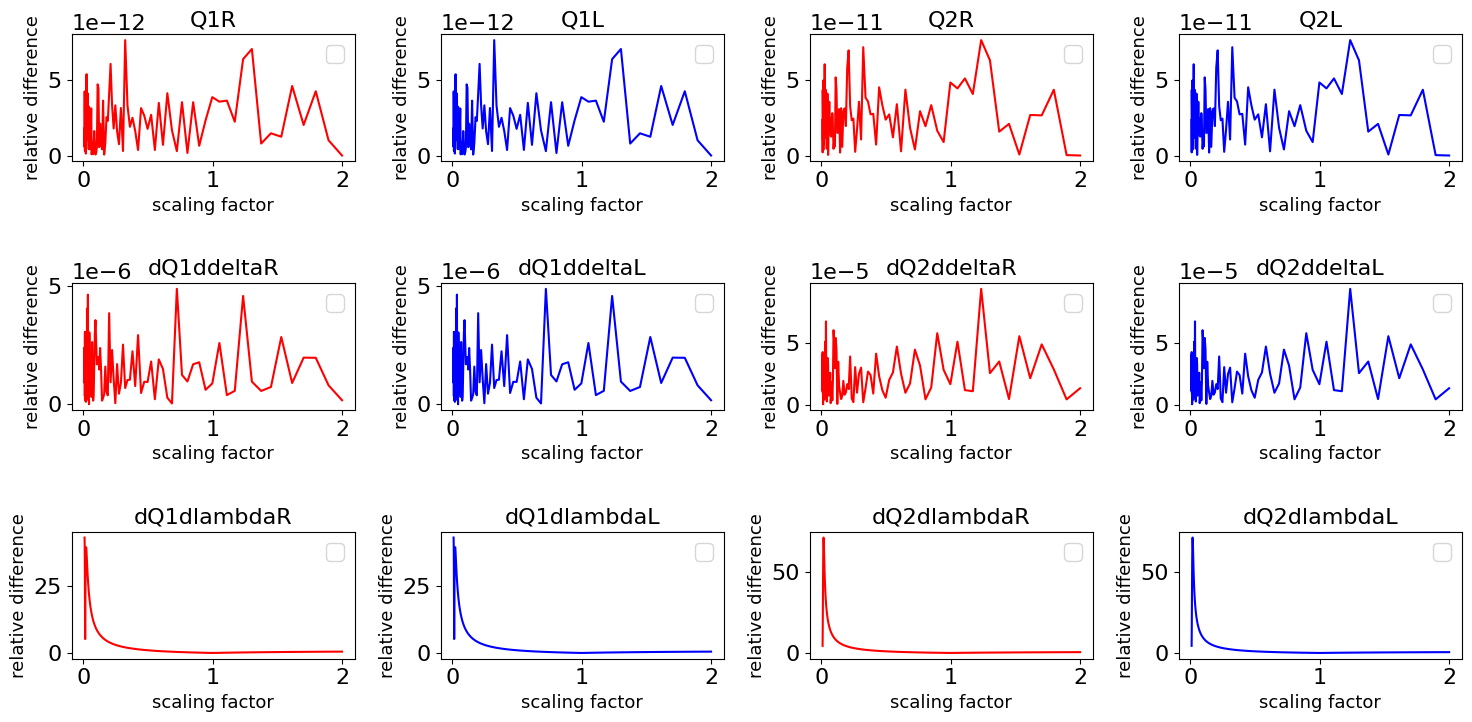

In [50]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4)

axes[0,0].plot(scales, Q1R_a, color='red')
axes[0,0].set_title('Q1R')
axes[0,0].set_xlabel('scaling factor', fontsize = 13)
axes[0,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,0].legend()

axes[0,1].plot(scales, Q1L_a, color='blue')
axes[0,1].set_title('Q1L')
axes[0,1].set_xlabel('scaling factor', fontsize = 13)
axes[0,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,1].legend()

axes[0,2].plot(scales, Q2R_a, color='red')
axes[0,2].set_title('Q2R')
axes[0,2].set_xlabel('scaling factor', fontsize = 13)
axes[0,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,2].legend()

axes[0,3].plot(scales, Q2L_a, color='blue')
axes[0,3].set_title('Q2L')
axes[0,3].set_xlabel('scaling factor', fontsize = 13)
axes[0,3].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,3].legend()

axes[1,0].plot(scales, dQ1ddeltaR_a, color='red')
axes[1,0].set_title('dQ1ddeltaR')
axes[1,0].set_xlabel('scaling factor', fontsize = 13)
axes[1,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,0].legend()

axes[1,1].plot(scales, dQ1ddeltaL_a, color='blue')
axes[1,1].set_title('dQ1ddeltaL')
axes[1,1].set_xlabel('scaling factor', fontsize = 13)
axes[1,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,1].legend()

axes[1,2].plot(scales, dQ2ddeltaR_a, color='red')
axes[1,2].set_title('dQ2ddeltaR')
axes[1,2].set_xlabel('scaling factor', fontsize = 13)
axes[1,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,2].legend()

axes[1,3].plot(scales, dQ2ddeltaL_a, color='blue')
axes[1,3].set_title('dQ2ddeltaL')
axes[1,3].set_xlabel('scaling factor', fontsize = 13)
axes[1,3].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,3].legend()

axes[2,0].plot(scales, dQ1dlambdaR_a, color='red')
axes[2,0].set_title('dQ1dlambdaR')
axes[2,0].set_xlabel('scaling factor', fontsize = 13)
axes[2,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,0].legend()

axes[2,1].plot(scales, dQ1dlambdaL_a, color='blue')
axes[2,1].set_title('dQ1dlambdaL')
axes[2,1].set_xlabel('scaling factor', fontsize = 13)
axes[2,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,1].legend()

axes[2,2].plot(scales, dQ2dlambdaR_a, color='red')
axes[2,2].set_title('dQ2dlambdaR')
axes[2,2].set_xlabel('scaling factor', fontsize = 13)
axes[2,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,2].legend()

axes[2,3].plot(scales, dQ2dlambdaL_a, color='blue')
axes[2,3].set_title('dQ2dlambdaL')
axes[2,3].set_xlabel('scaling factor', fontsize = 13)
axes[2,3].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,3].legend()

plt.tight_layout()

C:\Users\rosew\AppData\Local\Temp\ipykernel_29596\393199122.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_29596\393199122.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_29596\393199122.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_29596\393199122.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no 

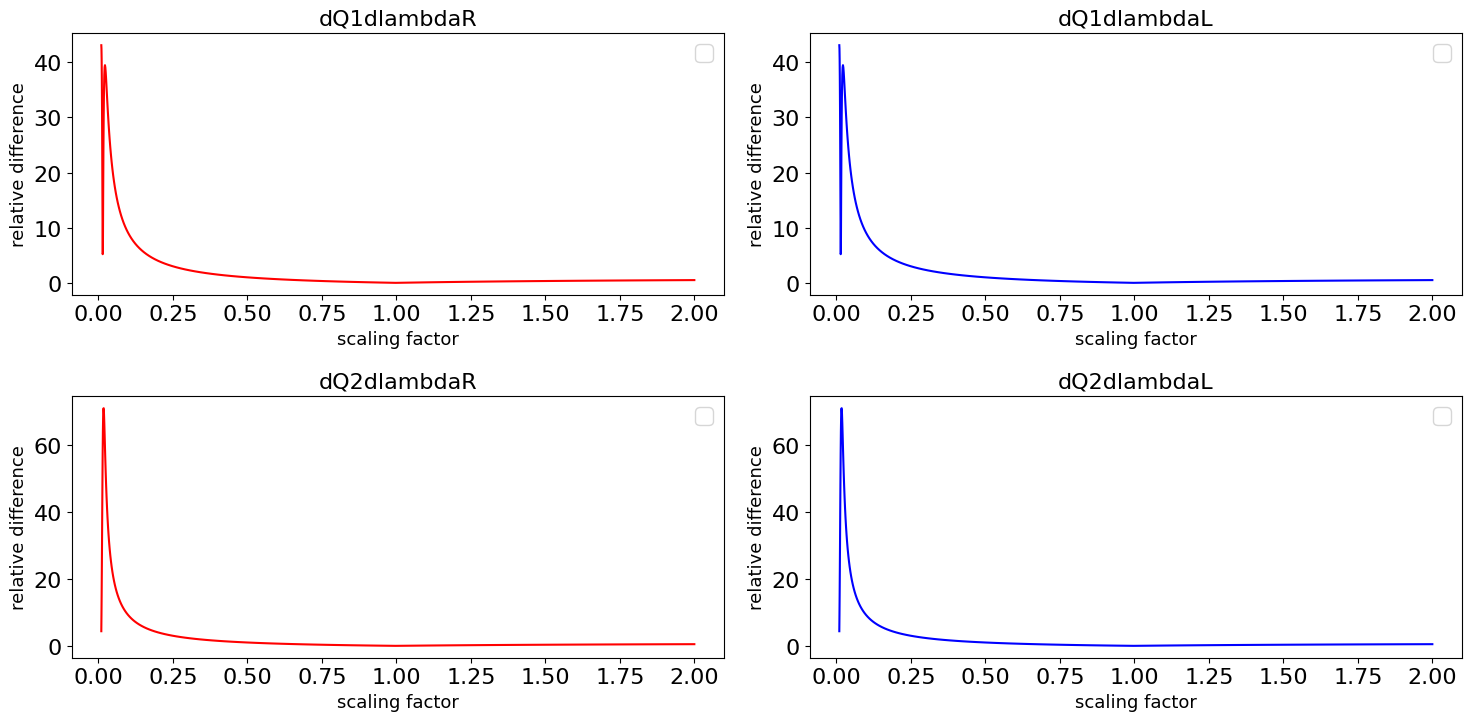

In [49]:
fig, axes = plt.subplots(2, 2)

axes[0,0].plot(scales, dQ1dlambdaR_a, color='red')
axes[0,0].set_title('dQ1dlambdaR')
axes[0,0].set_xlabel('scaling factor', fontsize = 13)
axes[0,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,0].legend()

axes[0,1].plot(scales, dQ1dlambdaL_a, color='blue')
axes[0,1].set_title('dQ1dlambdaL')
axes[0,1].set_xlabel('scaling factor', fontsize = 13)
axes[0,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,1].legend()

axes[1,0].plot(scales, dQ2dlambdaR_a, color='red')
axes[1,0].set_title('dQ2dlambdaR')
axes[1,0].set_xlabel('scaling factor', fontsize = 13)
axes[1,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,0].legend()

axes[1,1].plot(scales, dQ2dlambdaL_a, color='blue')
axes[1,1].set_title('dQ2dlambdaL')
axes[1,1].set_xlabel('scaling factor', fontsize = 13)
axes[1,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,1].legend()

plt.tight_layout()

In [53]:
DIFF_EFFICIENCIES[0]

array([1.78181487e-12, 2.36813764e-11, 5.17591286e-11, 8.01549104e-10,
       9.90000000e+01, 9.90000000e+01])

In [60]:
eff1s = []
eff2s = []
eff3s = []
eff4s = []
eff5s = []
eff6s = []

for i in range(0,len(scales)):

    efficiencies = DIFF_EFFICIENCIES[i]
    eff1 = DIFF_EFFICIENCIES[i][0]
    eff2 = DIFF_EFFICIENCIES[i][1]
    eff3 = DIFF_EFFICIENCIES[i][2]
    eff4 = DIFF_EFFICIENCIES[i][3]
    eff5 = DIFF_EFFICIENCIES[i][4]
    eff6 = DIFF_EFFICIENCIES[i][5]

    eff1s.append(eff1)
    eff2s.append(eff2)
    eff3s.append(eff3)
    eff4s.append(eff4)
    eff5s.append(eff5)
    eff6s.append(eff6)


C:\Users\rosew\AppData\Local\Temp\ipykernel_29596\482276455.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_29596\482276455.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_29596\482276455.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,2].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_29596\482276455.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no 

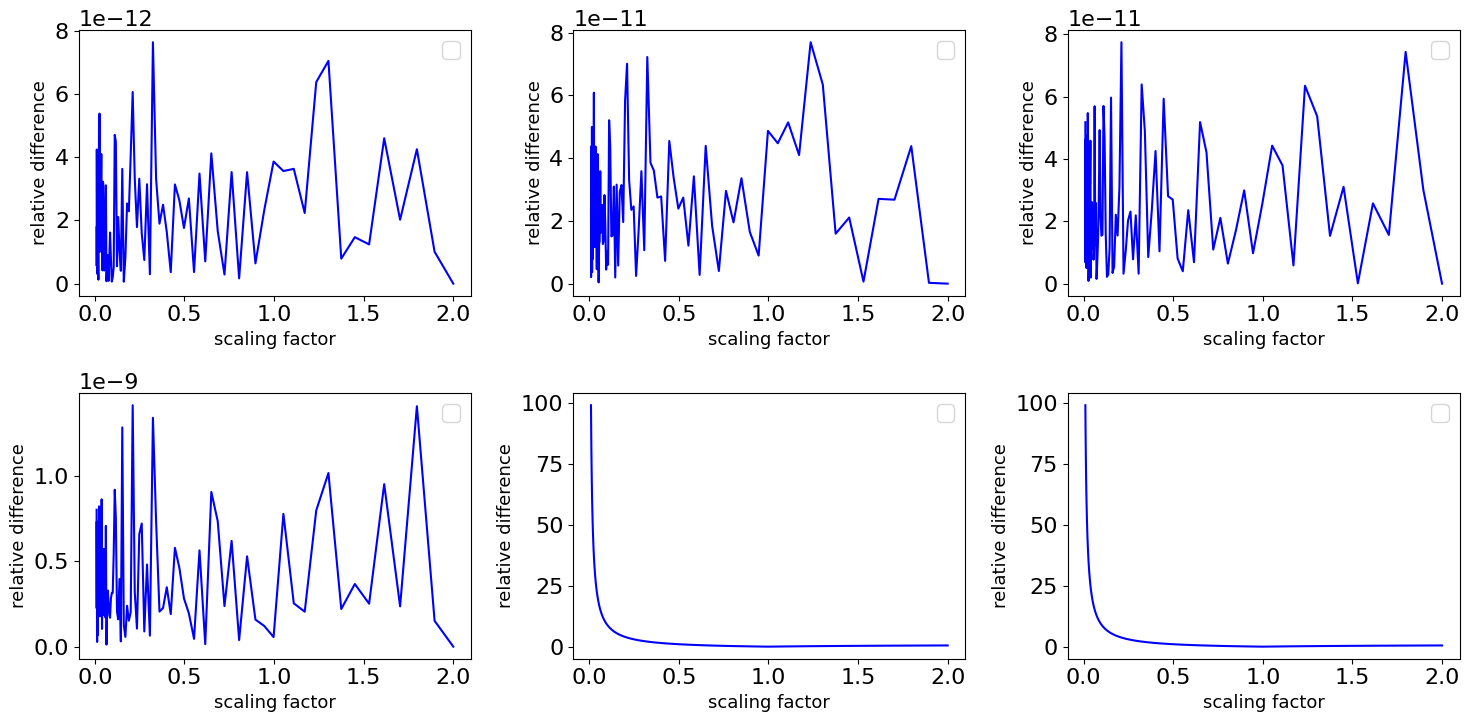

In [62]:
fig, axes = plt.subplots(2, 3)

axes[0,0].plot(scales, eff1s, color='blue')
axes[0,0].set_title('')
axes[0,0].set_xlabel('scaling factor', fontsize = 13)
axes[0,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,0].legend()

axes[0,1].plot(scales, eff2s, color='blue')
axes[0,1].set_title('')
axes[0,1].set_xlabel('scaling factor', fontsize = 13)
axes[0,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,1].legend()

axes[0,2].plot(scales, eff3s, color='blue')
axes[0,2].set_title('')
axes[0,2].set_xlabel('scaling factor', fontsize = 13)
axes[0,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,2].legend()

axes[1,0].plot(scales, eff4s, color='blue')
axes[1,0].set_title('')
axes[1,0].set_xlabel('scaling factor', fontsize = 13)
axes[1,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,0].legend()

axes[1,1].plot(scales, eff5s, color='blue')
axes[1,1].set_title('')
axes[1,1].set_xlabel('scaling factor', fontsize = 13)
axes[1,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,1].legend()

axes[1,2].plot(scales, eff6s, color='blue')
axes[1,2].set_title('')
axes[1,2].set_xlabel('scaling factor', fontsize = 13)
axes[1,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,2].legend()

plt.tight_layout()